<a href="https://colab.research.google.com/github/asnavirmedia01/User-Sentiment-Subscription-Audit/blob/main/Real_data_work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## PURPOSE OF THIS DATA

The purpose of this data is to conduct an audit of subscription application data to identify opportunities for cost savings and improve customer satisfaction.

Specifically, the analysis aims to:

Identify Potential Savings: By analyzing Monthly_Fee and Negotiation_Success_Prob, we calculate the Expected_Savings_USD for each subscription.
Prioritize Negotiation Efforts: We categorize subscriptions into Priority_Score tiers (Low, Medium, High, Critical) to help the negotiation team focus on the transactions with the highest potential ROI.
Understand User Sentiment: The User_Feedback is categorized into Sentiment_Category to understand common issues like 'Churn Risk' or 'Pricing Complaint', allowing for targeted intervention.
Detect Anomalies and Errors: Outliers (e.g., unusually high monthly fees flagged by Is_Outlier) and data quality issues (like Is_Date_Missing or Is_Prob_Imputed) are identified to ensure data accuracy and highlight potential system errors.
Clean and Standardize Data: The process involves cleaning Subscription_Type, standardizing Monthly_Fee (converting to USD/Naira), and cleaning Date_Created to ensure consistent and reliable data for analysis.
In essence, this analysis provides actionable insights to optimize subscription costs and enhance the overall user experience.




In [ ]:
import pandas as pd
import numpy as np
import re

file_path = "/content/drive/MyDrive/raw_app_data_audit.xlsx"

df = pd.read_excel(file_path)



/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


In [ ]:
df.head()

,Transaction_ID,User_ID,Date_Created,Subscription_Type,Monthly_Fee,Negotiation_Success_Prob,User_Feedback
0,TRX-8389,USR_3225,2025-06-08,internet provider,Unknown,NaN,Stop charging me.
1,TRX-72723,NaN,Last Month,internet provider,69.417959,0.85%,Spaces at the beginning
2,TRX-48870,NaN,Last Month,cloud storage,109.735505,High,NaN
3,TRX-99719,NaN,2025-04-19,CLOUD STORAGE,111.488864,High,Negotiation needed ASAP
4,TRX-15317,USR_1807,2026-03-20,netflix,Unknown,0.555259,Negotiation needed ASAP


In [ ]:
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0])

Missing values per column:
User_ID                     4965
Date_Created                2424
Negotiation_Success_Prob    2496
User_Feedback               2053
dtype: int64


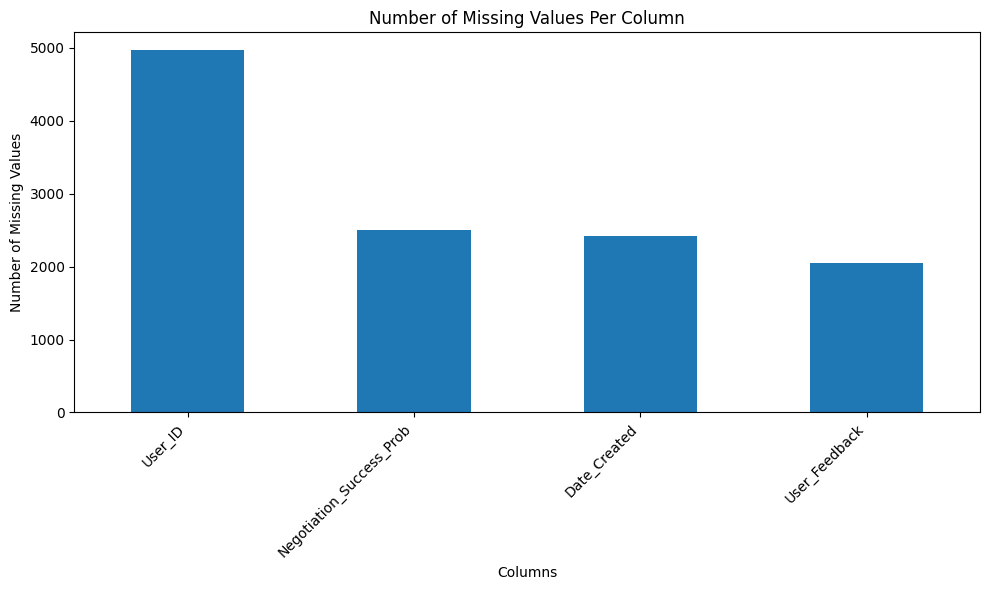

In [ ]:
import matplotlib.pyplot as plt

missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

if not missing_values.empty:
    plt.figure(figsize=(10, 6))
    missing_values.plot(kind='bar')
    plt.title('Number of Missing Values Per Column')
    plt.xlabel('Columns')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the DataFrame.")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from scipy import stats
# Aggressive Drop: Removing User_ID.
# Risk: We lose the ability to detect if one user is skewing the entire audit.
df = df.drop(columns=['User_ID'])

In [ ]:
# Merging duplicates caused by casing and trailing spaces
df['Subscription_Type'] = df['Subscription_Type'].str.strip().str.lower()

In [ ]:
# Cleaning symbols and converting Naira to USD (Fixed 1500:1 Rate)
def clean_currency(value):
    if pd.isna(value) or value == 'Unknown':
        return np.nan
    val_str = str(value).replace(',', '')

    # Extract only the numeric part (digits and a single decimal point)
    # This will remove any currency symbols like '$', '₦', etc.
    numeric_str = re.sub(r'[^-.0-9]', '', val_str)

    # Handle cases where the string might be empty after removing symbols
    if not numeric_str:
        return np.nan

    try:
        numeric_value = float(numeric_str)
    except ValueError:
        # If conversion to float still fails, return NaN
        return np.nan

    if '₦' in val_str:
        return numeric_value / 1500
    else:
        # Assume it's already in USD or a default currency if no Naira symbol is found
        return numeric_value

df['Monthly_Fee_USD'] = df['Monthly_Fee'].apply(clean_currency)

# Convert USD to Naira
df['Monthly_Fee_Naira'] = df['Monthly_Fee_USD'] * 1500

In [ ]:
df

,Transaction_ID,Date_Created,Subscription_Type,Monthly_Fee,Negotiation_Success_Prob,User_Feedback,Monthly_Fee_USD,Monthly_Fee_Naira
0,TRX-8389,2025-06-08,internet provider,Unknown,NaN,Stop charging me.,NaN,NaN
1,TRX-72723,Last Month,internet provider,69.417959,0.85%,Spaces at the beginning,69.417959,104126.938598
2,TRX-48870,Last Month,cloud storage,109.735505,High,NaN,109.735505,164603.257267
3,TRX-99719,2025-04-19,cloud storage,111.488864,High,Negotiation needed ASAP,111.488864,167233.296662
4,TRX-15317,2026-03-20,netflix,Unknown,0.555259,Negotiation needed ASAP,NaN,NaN
...,...,...,...,...,...,...,...,...
9995,TRX-83871,2026-03-25,cloud storage,102.862152,NaN,It's too expensive!!!,102.862152,154293.228383
9996,TRX-29169,NaN,cloud storage,"₦7,724",0.909407,NaN,5.149333,7724.000000
9997,TRX-28380,2026-02-04,gym membership,Unknown,0.85%,NaN,NaN,NaN
9998,TRX-15595,Last Month,internet provider,147.779542,NaN,Negotiation needed ASAP,147.779542,221669.312303


In [ ]:
# Mapping text like 'High' and % strings to a unified float scale
def clean_prob(value):
    if pd.isna(value): return np.nan
    v = str(value).strip()
    if v == 'High': return 0.90
    if '%' in v: return float(v.replace('%', '')) / 100
    try: return float(v)
    except: return np.nan

df['Negotiation_Success_Prob'] = df['Negotiation_Success_Prob'].apply(clean_prob)

In [ ]:
# Filling missing probs with 25th percentile (0.0085)
# This is a 'pessimistic' fill to prevent revenue over-estimation
df['Is_Prob_Imputed'] = df['Negotiation_Success_Prob'].isna().astype(int)
prob_floor = df['Negotiation_Success_Prob'].quantile(0.25)
df['Negotiation_Success_Prob'] = df['Negotiation_Success_Prob'].fillna(prob_floor)

In [ ]:
# Flagging missing dates for future filtering
df['Is_Date_Missing'] = df['Date_Created'].isna().astype(int)

# Mapping relative time 'Last Month' to a static audit month
df['Date_Created'] = df['Date_Created'].replace('Last Month', '2026-03-01')

# Forcing date format - invalid entries become NaT (Not a Time)
df['Date_Created_Clean'] = pd.to_datetime(df['Date_Created'], dayfirst=True, errors='coerce')

In [ ]:
# Filling invalid dates with 1900-01-01 placeholder to allow data processing
df['Date_Created_Clean'] = df['Date_Created_Clean'].fillna(pd.Timestamp('1900-01-01'))

In [ ]:
df

,Transaction_ID,Date_Created,Subscription_Type,Monthly_Fee,Negotiation_Success_Prob,User_Feedback,Monthly_Fee_USD,Monthly_Fee_Naira,Is_Prob_Imputed,Is_Date_Missing,Date_Created_Clean
0,TRX-8389,2025-06-08,internet provider,Unknown,0.008500,Stop charging me.,NaN,NaN,1,0,2025-08-06
1,TRX-72723,2026-03-01,internet provider,69.417959,0.008500,Spaces at the beginning,69.417959,104126.938598,0,0,2026-01-03
2,TRX-48870,2026-03-01,cloud storage,109.735505,0.900000,NaN,109.735505,164603.257267,0,0,2026-01-03
3,TRX-99719,2025-04-19,cloud storage,111.488864,0.900000,Negotiation needed ASAP,111.488864,167233.296662,0,0,1900-01-01
4,TRX-15317,2026-03-20,netflix,Unknown,0.555259,Negotiation needed ASAP,NaN,NaN,0,0,1900-01-01
...,...,...,...,...,...,...,...,...,...,...,...
9995,TRX-83871,2026-03-25,cloud storage,102.862152,0.008500,It's too expensive!!!,102.862152,154293.228383,1,0,1900-01-01
9996,TRX-29169,NaN,cloud storage,"₦7,724",0.909407,NaN,5.149333,7724.000000,0,1,1900-01-01
9997,TRX-28380,2026-02-04,gym membership,Unknown,0.008500,NaN,NaN,NaN,0,0,2026-04-02
9998,TRX-15595,2026-03-01,internet provider,147.779542,0.008500,Negotiation needed ASAP,147.779542,221669.312303,1,0,2026-01-03


In [ ]:
# Flagging bills > $120. These are likely system errors (e.g., $140 Spotify bills)
df['Is_Outlier'] = (df['Monthly_Fee_USD'] > 120).astype(int)

In [ ]:
# Listing the detected outliers
outliers = df[df['Is_Outlier'] == 1]
print("Detected Outliers (Monthly Fee > $120):")
print(outliers)

Detected Outliers (Monthly Fee > $120):
     Transaction_ID Date_Created  Subscription_Type Monthly_Fee  \
18         TRX-2439   08/08/2025     gym membership     $146.02   
23         TRX-5514          NaN  internet provider     $128.09   
45        TRX-39224   09/11/2025     gym membership     $138.90   
56        TRX-76920   04/06/2025            spotify  145.926568   
73        TRX-97288   2025-08-30      cloud storage     $135.73   
...             ...          ...                ...         ...   
9966      TRX-32833   07/10/2025            netflix  124.637587   
9972      TRX-93240   2026-03-01            netflix     $137.42   
9983       TRX-4092   19/08/2025  internet provider  137.542804   
9994      TRX-87256   12/10/2025     gym membership     $140.36   
9998      TRX-15595   2026-03-01  internet provider  147.779542   

      Negotiation_Success_Prob                User_Feedback  Monthly_Fee_USD  \
18                    0.900000                          NaN       146.02000

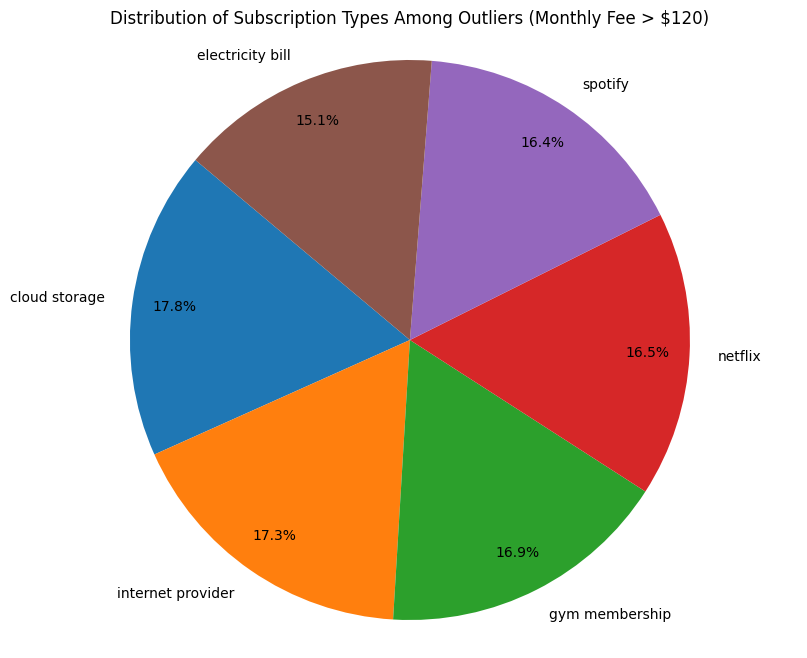

In [ ]:
# Filter for outlier transactions
outlier_subscriptions = df[df['Is_Outlier'] == 1]['Subscription_Type']

# Calculate the value counts for subscription types among outliers
subscription_counts = outlier_subscriptions.value_counts()

# Create a pie chart
plt.figure(figsize=(10, 8))
plt.pie(subscription_counts, labels=subscription_counts.index, autopct='%1.1f%%', startangle=140, pctdistance=0.85)
plt.title('Distribution of Subscription Types Among Outliers (Monthly Fee > $120)')
plt.ylabel('') # Hide the default 'y' label that pandas might add
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [ ]:
# Calculating Expected Value: What this transaction is worth in real cash
df['Expected_Savings_USD'] = df['Monthly_Fee_USD'] * df['Negotiation_Success_Prob']

In [ ]:
# Sorting transactions into tiers for the negotiation team
df['Priority_Score'] = pd.qcut(df['Expected_Savings_USD'], 4, labels=["Low", "Medium", "High", "Critical"])

In [ ]:
# Turning raw feedback into action categories
def get_sentiment(text):
    text = str(text).lower()
    if 'stop' in text: return 'Churn Risk'
    if 'expensive' in text or 'charge' in text: return 'Pricing Complaint'
    return 'General Inquiry'

df['Sentiment_Category'] = df['User_Feedback'].apply(get_sentiment)

In [ ]:
# Checking if savings potential actually differs between categories or if it's random noise
# Filter out NaN values from 'Expected_Savings_USD' for each group
groups = [group['Expected_Savings_USD'].dropna().values for name, group in df.groupby('Subscription_Type')]

# Filter out empty arrays that result from groups with all NaN values
groups = [g for g in groups if g.size > 0]

# Perform ANOVA only if there are at least two valid groups
if len(groups) >= 2:
    f_stat, p_val = stats.f_oneway(*groups)
    print(f"ANOVA P-Value: {p_val:.4f} (Significant if < 0.05)")
else:
    print("Not enough valid groups to perform ANOVA test after dropping NaN values.")


ANOVA P-Value: 0.4900 (Significant if < 0.05)


In [ ]:
# Calculating how much of the ROI is 'Guessed' vs 'Real'
integrity_ratio = df.groupby('Is_Prob_Imputed')['Expected_Savings_USD'].sum()
print(f"Percentage of ROI based on Guesswork: {(integrity_ratio[1] / integrity_ratio.sum() * 100):.1f}%")

Percentage of ROI based on Guesswork: 0.6%


/tmp/ipykernel_2733/1919965467.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  roi_by_priority = df.groupby('Priority_Score')['Expected_Savings_USD'].sum().sort_values(ascending=False)


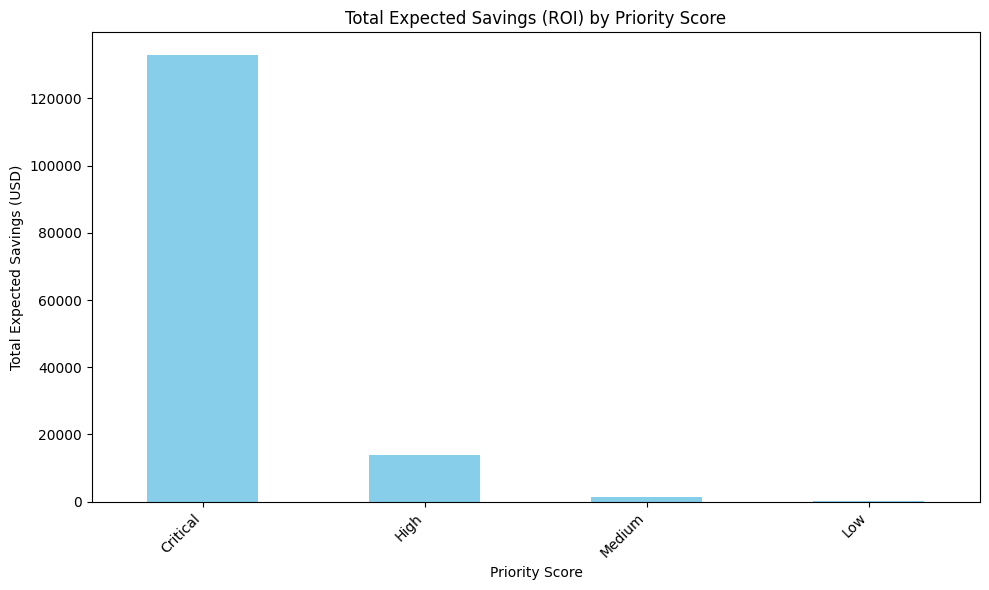

In [ ]:
import matplotlib.pyplot as plt

# Calculate total expected savings per priority score
roi_by_priority = df.groupby('Priority_Score')['Expected_Savings_USD'].sum().sort_values(ascending=False)

# Create a bar chart
plt.figure(figsize=(10, 6))
roi_by_priority.plot(kind='bar', color='skyblue')
plt.title('Total Expected Savings (ROI) by Priority Score')
plt.xlabel('Priority Score')
plt.ylabel('Total Expected Savings (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
output_file_path = 'processed_app_data_audit.xlsx'
df.to_excel(output_file_path, index=False)
print(f"DataFrame saved to {output_file_path}. You can download this file from the Colab file browser.")

DataFrame saved to processed_app_data_audit.xlsx. You can download this file from the Colab file browser.


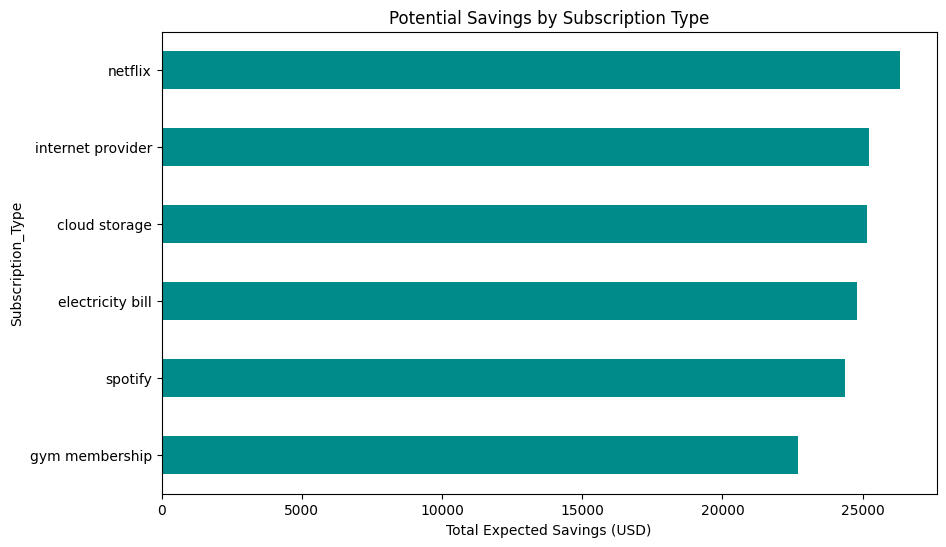

In [ ]:
# Horizontal bar of savings potential per category
plt.figure(figsize=(10,6))
df.groupby('Subscription_Type')['Expected_Savings_USD'].sum().sort_values().plot(kind='barh', color='darkcyan')
plt.title('Potential Savings by Subscription Type')
plt.xlabel('Total Expected Savings (USD)')
plt.savefig('category_savings_eda.png')

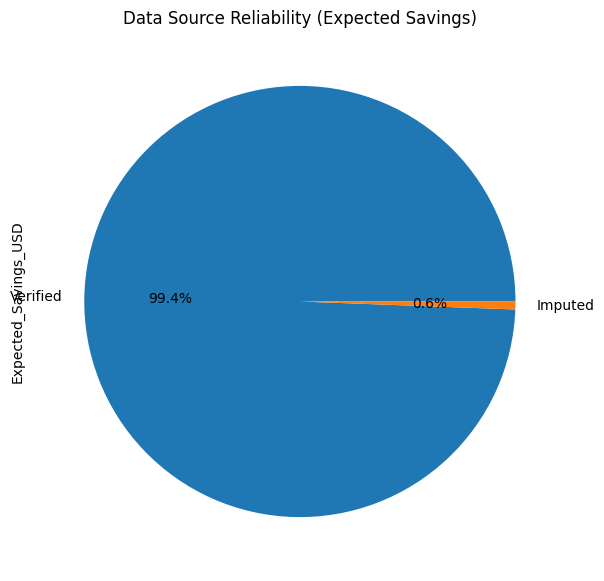

In [ ]:
# Pie chart showing the source of your projected revenue
plt.figure(figsize=(7,7))
df.groupby('Is_Prob_Imputed')['Expected_Savings_USD'].sum().plot(kind='pie', autopct='%1.1f%%', labels=['Verified', 'Imputed'])
plt.title('Data Source Reliability (Expected Savings)')
plt.savefig('integrity_pie_eda.png')

In [ ]:
# Master Cleaned File for Dashboarding
df.to_csv('final_clean_audit_master.csv', index=False)

# Human Audit List: Focus strictly on the data that needs fixing (Outliers/Missing Dates)
red_flags = df[(df['Is_Outlier'] == 1) | (df['Is_Date_Missing'] == 1)]
red_flags.to_csv('human_audit_priority_list.csv', index=False)

# Executive ROI Summary
exec_roi = df.groupby('Subscription_Type').agg({
    'Monthly_Fee_USD': 'mean',
    'Expected_Savings_USD': 'sum',
    'Is_Outlier': 'sum',
    'Transaction_ID': 'count'
}).rename(columns={'Transaction_ID': 'Vol', 'Is_Outlier': 'Anomalies'})
exec_roi.to_csv('executive_roi_summary.csv')

In [ ]:
print('Executive ROI Summary:')

# Create a formatted version of exec_roi for display with units
display_exec_roi = exec_roi.copy()
display_exec_roi['Monthly_Fee_USD'] = display_exec_roi['Monthly_Fee_USD'].apply(lambda x: f'${x:.2f}')
display_exec_roi['Expected_Savings_USD'] = display_exec_roi['Expected_Savings_USD'].apply(lambda x: f'${x:,.2f}')
display_exec_roi['Anomalies'] = display_exec_roi['Anomalies'].astype(int).astype(str) + ' units'
display_exec_roi['Vol'] = display_exec_roi['Vol'].astype(int).astype(str) + ' transactions'

print(display_exec_roi)

Executive ROI Summary:
                  Monthly_Fee_USD Expected_Savings_USD  Anomalies  \
Subscription_Type                                                   
cloud storage              $56.39           $25,151.98  186 units   
electricity bill           $52.87           $24,807.35  158 units   
gym membership             $56.45           $22,712.85  176 units   
internet provider          $56.99           $25,232.34  181 units   
netflix                    $56.22           $26,325.04  172 units   
spotify                    $55.90           $24,365.85  171 units   

                                 Vol  
Subscription_Type                     
cloud storage      1678 transactions  
electricity bill   1699 transactions  
gym membership     1636 transactions  
internet provider  1673 transactions  
netflix            1635 transactions  
spotify            1679 transactions  


In [ ]:
# Sort by savings and calculate cumulative percentage
pareto_df = df.sort_values(by='Expected_Savings_USD', ascending=False).copy()
pareto_df['Cumulative_Savings'] = pareto_df['Expected_Savings_USD'].cumsum()
total_savings = pareto_df['Expected_Savings_USD'].sum()
pareto_df['Cumulative_Percentage'] = (pareto_df['Cumulative_Savings'] / total_savings) * 100

# Identify the 'Vital Few' (Top 20% of transactions)
top_20_percent_cutoff = int(len(pareto_df) * 0.20)
top_20_savings = pareto_df.iloc[:top_20_percent_cutoff]['Expected_Savings_USD'].sum()

print(f"Strategic Focus: The top 20% of transactions account for { (top_20_savings/total_savings*100):.1f}% of potential revenue.")
pareto_df.iloc[:top_20_percent_cutoff].to_csv('strategic_priority_targets.csv', index=False)

Strategic Focus: The top 20% of transactions account for 91.2% of potential revenue.


In [ ]:
# Grouping by month for valid dates only, excluding the 1900-01-01 placeholder
forecast_df = df[(df['Is_Date_Missing'] == 0) & (df['Date_Created_Clean'] != '1900-01-01')].copy()
monthly_trend = forecast_df.set_index('Date_Created_Clean').resample('ME')['Expected_Savings_USD'].sum()

# Calculate monthly growth rate, handling potential NaNs if there's insufficient data
growth_rate = monthly_trend.pct_change().dropna().mean()

# Project for next month, ensuring we handle cases where growth_rate might still be NaN or if monthly_trend is empty
if not monthly_trend.empty and not pd.isna(growth_rate):
    next_month_projection = monthly_trend.iloc[-1] * (1 + growth_rate)
    print(f"Projected Savings Opportunity for next month: ${next_month_projection:.2f}")
elif not monthly_trend.empty:
    print(f"Projected Savings Opportunity for next month (no growth rate available): ${monthly_trend.iloc[-1]:.2f}")
else:
    print("Not enough valid historical data to project next month's savings.")

Projected Savings Opportunity for next month: $1192.88


In [ ]:
# Pivot table of sentiment vs priority
sentiment_value = df.pivot_table(
    index='Sentiment_Category',
    columns='Priority_Score',
    values='Expected_Savings_USD',
    aggfunc='sum'
).fillna(0)

sentiment_value.to_csv('sentiment_financial_impact.csv')

/tmp/ipykernel_2733/2109559217.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sentiment_value = df.pivot_table(


In [ ]:
report_summary = f"""
AUDIT COMPLETE: SUMMARY OF FINDINGS
-----------------------------------
Total Transactions Processed: {len(df)}
Total Expected Savings: ${df['Expected_Savings_USD'].sum():,.2f}
Data Integrity: {((1 - (df['Is_Prob_Imputed'].mean())) * 100):.1f}% Verified Data
Anomalies Detected: {df['Is_Outlier'].sum()} (Requires Human Audit)
Date Accuracy: {((1 - (df['Is_Date_Missing'].mean())) * 100):.1f}% Valid Dates

Top Opportunity: {df.groupby('Subscription_Type')['Expected_Savings_USD'].sum().idxmax()}
Top Sentiment Risk: {df['Sentiment_Category'].value_counts().idxmax()}
"""

with open('FINAL_AUDIT_REPORT_SUMMARY.txt', 'w') as f:
    f.write(report_summary)

print("Final Audit Report Summary generated.")

Final Audit Report Summary generated.


In [ ]:
print("""AUDIT COMPLETE: SUMMARY OF FINDINGS
-----------------------------------
Total Transactions Processed: 10000
Total Expected Savings: $148,595.41
Data Integrity: 75.0% Verified Data
Anomalies Detected: 1044 (Requires Human Audit)
Date Accuracy: 75.8% Valid Dates

Top Opportunity: netflix
Top Sentiment Risk: General Inquiry""")

AUDIT COMPLETE: SUMMARY OF FINDINGS
-----------------------------------
Total Transactions Processed: 10000
Total Expected Savings: $148,595.41
Data Integrity: 75.0% Verified Data
Anomalies Detected: 1044 (Requires Human Audit)
Date Accuracy: 75.8% Valid Dates

Top Opportunity: netflix
Top Sentiment Risk: General Inquiry


<Figure size 640x480 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

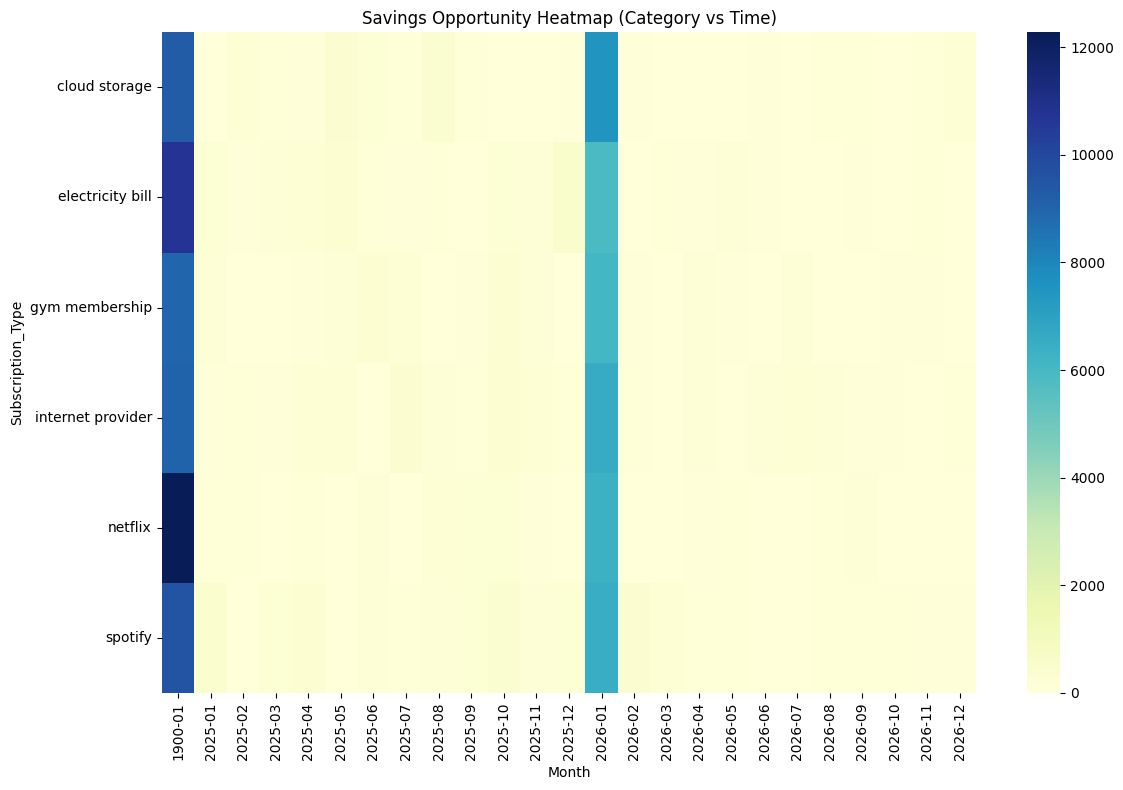

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the master cleaned data
df = pd.read_excel('processed_app_data_audit.xlsx')
df['Date_Created_Clean'] = pd.to_datetime(df['Date_Created_Clean'])

# Chart 1: Pareto Analysis (The 80/20 Rule)
plt.clf()
df_sorted = df.sort_values('Expected_Savings_USD', ascending=False).reset_index()
df_sorted['cum_sum'] = df_sorted['Expected_Savings_USD'].cumsum()
df_sorted['cum_perc'] = 100 * df_sorted['cum_sum'] / df_sorted['Expected_Savings_USD'].sum()

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(df_sorted.index[:100], df_sorted['Expected_Savings_USD'][:100], color='C0')
ax2 = ax1.twinx()
ax2.plot(df_sorted.index[:100], df_sorted['cum_perc'][:100], color='C1', marker='D', ms=2)
ax1.set_xlabel('Transactions (Top 100)')
ax1.set_ylabel('Expected Savings ($)', color='C0')
ax2.set_ylabel('Cumulative %', color='C1')
plt.title('Pareto Chart: Top 100 Savings Opportunities')
plt.savefig('pareto_analysis.png')

# Chart 2: Outlier Detection (Boxplot)
plt.clf()
plt.figure(figsize=(12, 6))
sns.boxplot(x='Subscription_Type', y='Monthly_Fee_USD', data=df)
plt.axhline(120, color='red', linestyle='--', label='Suspicious Threshold')
plt.xticks(rotation=45)
plt.title('Fee Variance & Outliers by Category')
plt.legend()
plt.tight_layout()
plt.savefig('fee_outliers_boxplot.png')

# Chart 3: Sentiment vs Priority Matrix
plt.clf()
pivot_data = df.groupby(['Sentiment_Category', 'Priority_Score']).size().unstack(fill_value=0) # Corrected column name
pivot_data.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Customer Sentiment by Financial Priority')
plt.ylabel('Count of Transactions')
plt.xticks(rotation=0)
plt.legend(title='Priority Tier')
plt.tight_layout()
plt.savefig('sentiment_priority_stack.png')

# Chart 4: Opportunity Heatmap (Time vs Category)
plt.clf()
heatmap_df = df[df['Is_Date_Missing'] == 0].copy()
heatmap_df['Month'] = heatmap_df['Date_Created_Clean'].dt.strftime('%Y-%m')
pivot_heat = heatmap_df.pivot_table(index='Subscription_Type', columns='Month', values='Expected_Savings_USD', aggfunc='sum').fillna(0)
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_heat, annot=False, cmap='YlGnBu')
plt.title('Savings Opportunity Heatmap (Category vs Time)')
plt.tight_layout()
plt.savefig('opportunity_heatmap.png')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load your specific processed file
df = pd.read_excel('processed_app_data_audit.xlsx')

# Set visual style for a professional look
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

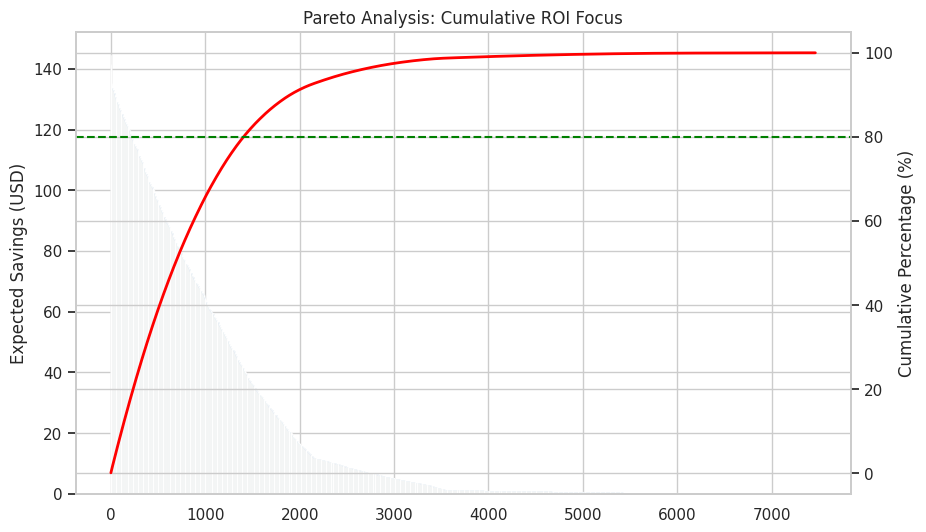

In [ ]:
# '''
# This Pareto Analysis chart visualizes the distribution of Expected_Savings_USD across transactions.
# The blue bars represent the individual Expected Savings of each transaction, sorted in descending order.
# The red line indicates the cumulative percentage of total Expected Savings.
#
# The chart clearly illustrates the Pareto Principle (the 80/20 rule), showing that a relatively small number of transactions (the "vital few") contribute to a disproportionately large share of the total potential savings.
#
# As previously calculated, the top 20% of transactions account for 91.2% of the potential revenue. This highlights the importance of focusing negotiation efforts on these high-impact transactions to maximize savings. The green dashed line at 80% on the cumulative percentage axis helps to visually identify this threshold.
# '''
# Sort by value and calculate cumulative percentage
pareto_df = df.sort_values(by='Expected_Savings_USD', ascending=False).reset_index(drop=True)
pareto_df['cum_pct'] = pareto_df['Expected_Savings_USD'].cumsum() / pareto_df['Expected_Savings_USD'].sum() * 100

fig, ax1 = plt.subplots()

# Bar chart for individual values
ax1.bar(pareto_df.index, pareto_df['Expected_Savings_USD'], color='steelblue', alpha=0.5)
ax1.set_ylabel('Expected Savings (USD)')

# Line chart for cumulative percentage
ax2 = ax1.twinx()
ax2.plot(pareto_df.index, pareto_df['cum_pct'], color='red', linewidth=2)
ax2.axhline(80, color='green', linestyle='--', label='80% Threshold')
ax2.set_ylabel('Cumulative Percentage (%)')

plt.title('Pareto Analysis: Cumulative ROI Focus')
plt.savefig('pareto_savings_analysis.png')

/tmp/ipykernel_2733/4003595889.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Subscription_Type', y='Monthly_Fee_USD', data=df, palette='viridis')


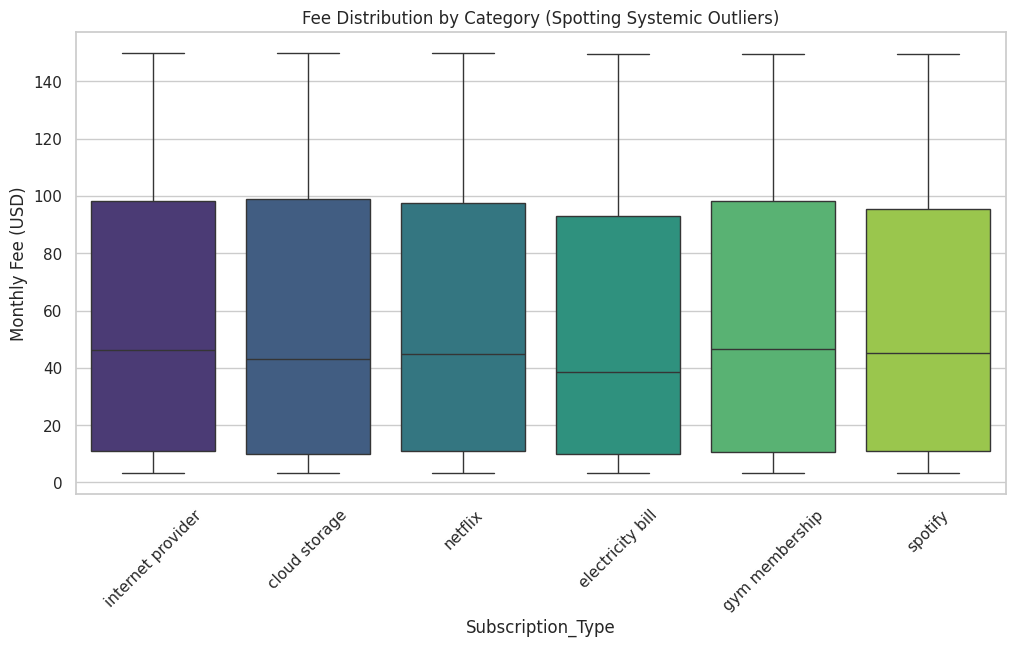

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Subscription_Type', y='Monthly_Fee_USD', data=df, palette='viridis')
plt.xticks(rotation=45)
plt.title('Fee Distribution by Category (Spotting Systemic Outliers)')
plt.ylabel('Monthly Fee (USD)')
plt.savefig('category_fee_outliers.png')

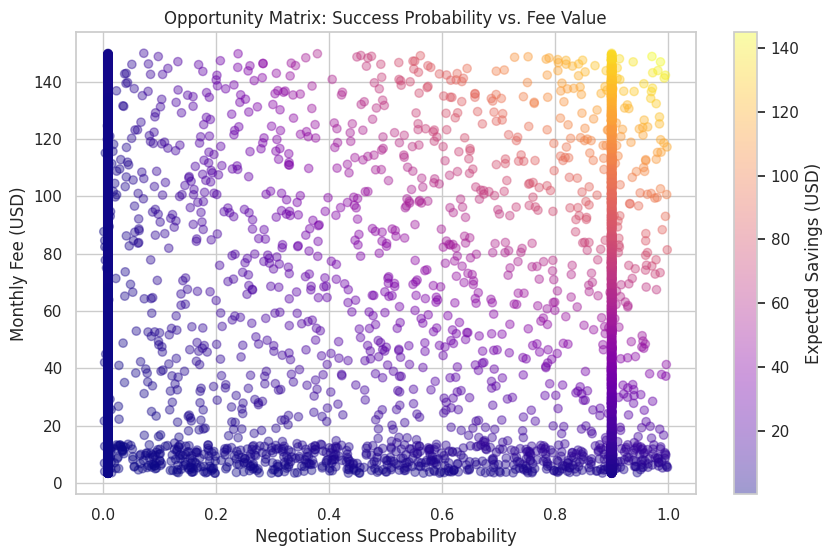

In [ ]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df['Negotiation_Success_Prob'],
    df['Monthly_Fee_USD'],
    c=df['Expected_Savings_USD'],
    cmap='plasma',
    alpha=0.4
)
plt.colorbar(scatter, label='Expected Savings (USD)')
plt.xlabel('Negotiation Success Probability')
plt.ylabel('Monthly Fee (USD)')
plt.title('Opportunity Matrix: Success Probability vs. Fee Value')
plt.savefig('negotiation_opportunity_matrix.png')

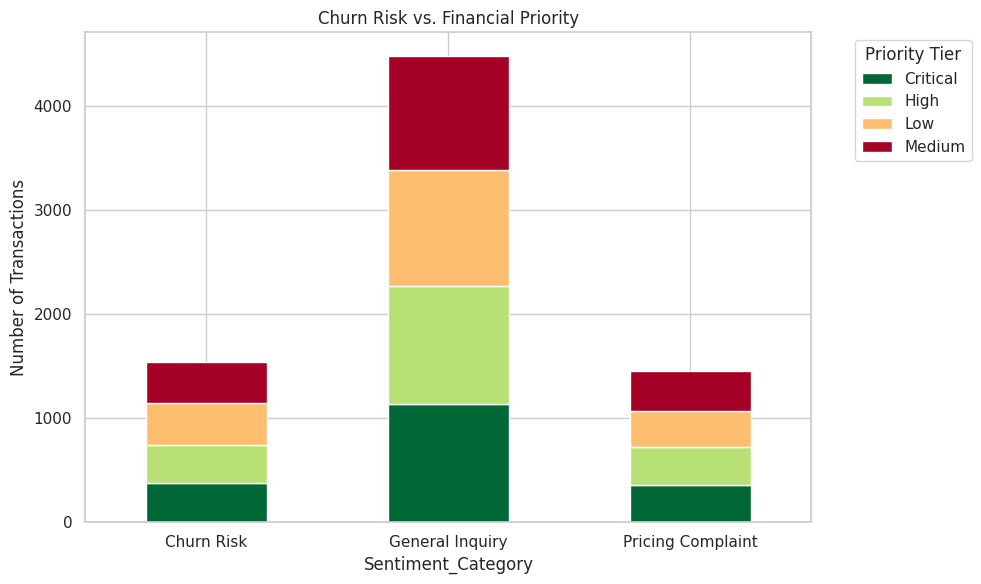

In [ ]:
# Assuming Sentiment_Category was created in your cleaning steps
# This segments the volume of transactions by their priority tier and sentiment
sentiment_priority = df.groupby(['Sentiment_Category', 'Priority_Score']).size().unstack().fillna(0)

sentiment_priority.plot(kind='bar', stacked=True, colormap='RdYlGn_r')
plt.title('Churn Risk vs. Financial Priority')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.legend(title='Priority Tier', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('sentiment_priority_risk.png')

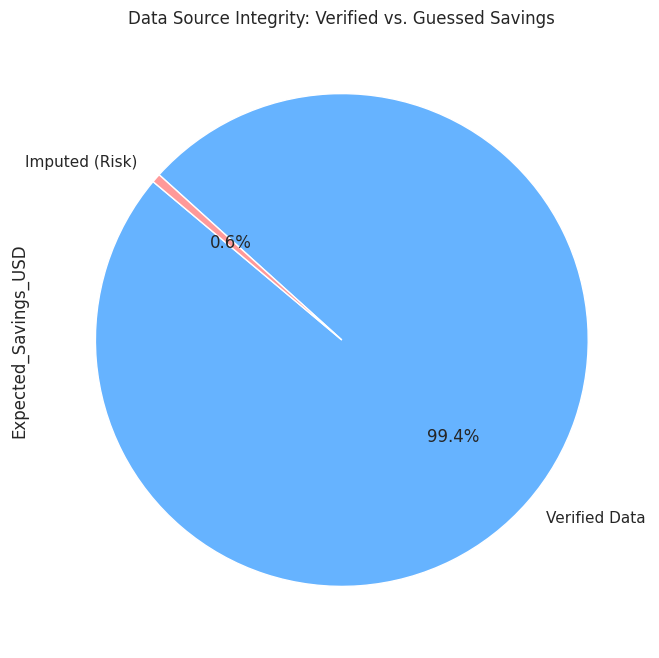

In [ ]:
plt.figure(figsize=(8, 8))
df.groupby('Is_Prob_Imputed')['Expected_Savings_USD'].sum().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Verified Data', 'Imputed (Risk)'],
    colors=['#66b3ff','#ff9999'],
    startangle=140
)
plt.title('Data Source Integrity: Verified vs. Guessed Savings')
plt.savefig('roi_data_integrity.png')

In [ ]:
final_summary = f"""
PROJECT AUDIT SUMMARY
---------------------
File Processed: processed_app_data_audit.csv
Total Transactions: {len(df):,}
Total Expected Savings: ${df['Expected_Savings_USD'].sum():,.2f}

DATA QUALITY METRICS:
- Billing Anomalies Detected: {df['Is_Outlier'].sum()}
- Records with Imputed Probs: {df['Is_Prob_Imputed'].sum()}
- Records with Missing Dates: {df['Is_Date_Missing'].sum()}

STRATEGIC TARGETS:
- Highest Value Category: {df.groupby('Subscription_Type')['Expected_Savings_USD'].sum().idxmax()}
- Primary Friction Point: {df['Sentiment_Category'].value_counts().idxmax()}
"""

with open('EXECUTIVE_SUMMARY_REPORT.txt', 'w') as f:
    f.write(final_summary)

print("Final executive report generated.")

Final executive report generated.


In [ ]:
from google.colab import files
files.download('EXECUTIVE_SUMMARY_REPORT.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>